La imagen tiene 4494 filas y 2996 columnas.
La ventana tiene 568 filas y 583 columnas.


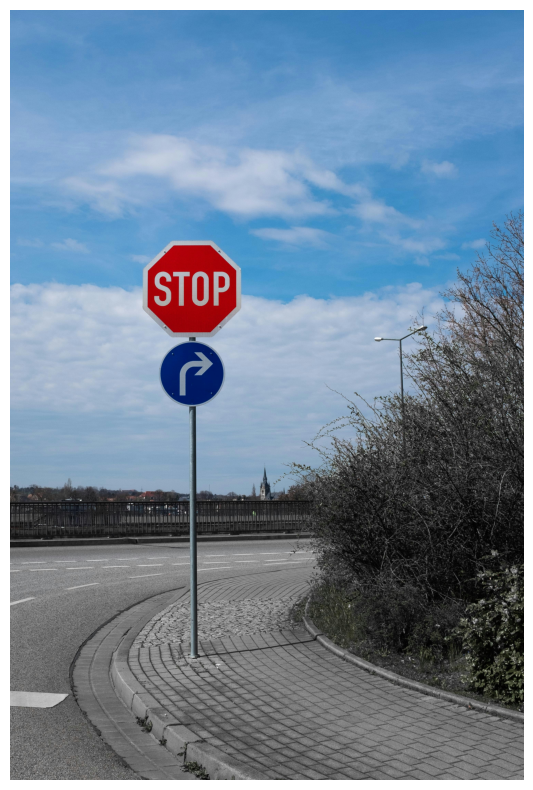

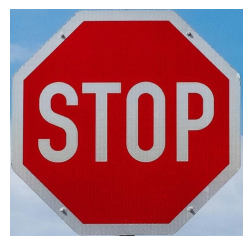

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint

imagen = cv2.imread('foto.jpg')
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(imagen)
plt.axis("off")
filas_i, columnas_i = imagen.shape[:2]
print(f'La imagen tiene {filas_i} filas y {columnas_i} columnas.')      

ventana = cv2.imread('signal.jpg')
ventana = cv2.cvtColor(ventana, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(3, 3))
plt.imshow(ventana)
plt.axis("off")
filas_v, columnas_v = ventana.shape[:2]
print(f'La ventana tiene {filas_v} filas y {columnas_v} columnas.')

Número de posiciones posibles: 459


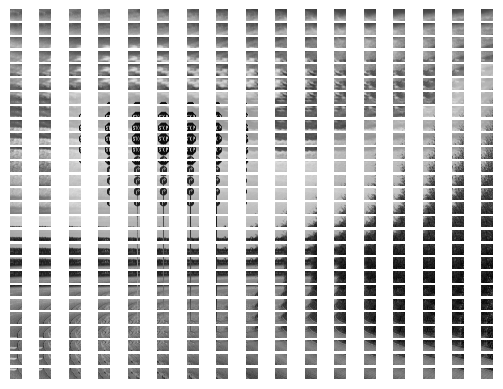

In [3]:

imagen_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
ventana_gray = cv2.cvtColor(ventana, cv2.COLOR_BGR2GRAY)

stride = 150

filas_stride = (filas_i - filas_v) // stride + 1
columnas_stride = (columnas_i - columnas_v) // stride + 1

print(f'Número de posiciones posibles: {filas_stride * columnas_stride}')

distancias = [[0 for _ in range(columnas_stride)] for _ in range(filas_stride)]

for i in range(filas_stride):
    for j in range(columnas_stride):
        # Extraer la ventana de la imagen
        segmento = imagen_gray[i*stride:(i*stride)+filas_v, j*stride:(j*stride)+columnas_v]
                      
        plt.subplot(filas_stride, columnas_stride, i*columnas_stride + j + 1)
        plt.imshow(segmento, cmap='gray')
        plt.axis("off")
        

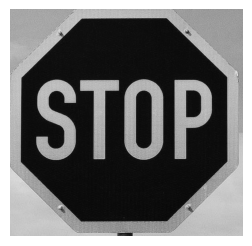

In [4]:

stride = 25

i = 54
j = 31

segmento = imagen_gray[i*stride:(i*stride)+filas_v, j*stride:(j*stride)+columnas_v]

plt.figure(figsize=(3, 3))
plt.imshow(segmento, cmap='gray')
plt.axis("off")

ventana_gray = segmento


158 97
Procesando 15326 posiciones...
Procesados 97 objetos... (0.63%)
Procesados 194 objetos... (1.27%)
Procesados 291 objetos... (1.90%)
Procesados 388 objetos... (2.53%)
Procesados 485 objetos... (3.16%)
Procesados 582 objetos... (3.80%)
Procesados 679 objetos... (4.43%)
Procesados 776 objetos... (5.06%)
Procesados 873 objetos... (5.70%)
Procesados 970 objetos... (6.33%)
Procesados 1067 objetos... (6.96%)
Procesados 1164 objetos... (7.59%)
Procesados 1261 objetos... (8.23%)
Procesados 1358 objetos... (8.86%)
Procesados 1455 objetos... (9.49%)
Procesados 1552 objetos... (10.13%)
Procesados 1649 objetos... (10.76%)
Procesados 1746 objetos... (11.39%)
Procesados 1843 objetos... (12.03%)
Procesados 1940 objetos... (12.66%)
Procesados 2037 objetos... (13.29%)
Procesados 2134 objetos... (13.92%)
Procesados 2231 objetos... (14.56%)
Procesados 2328 objetos... (15.19%)
Procesados 2425 objetos... (15.82%)
Procesados 2522 objetos... (16.46%)
Procesados 2619 objetos... (17.09%)
Procesados 2716 

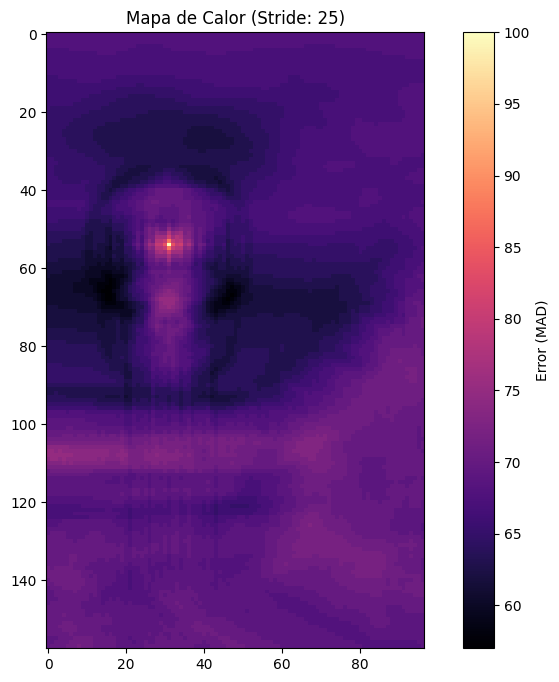

In [5]:

# Cálculo de MAD

stride = 25
filas_stride = (filas_i - filas_v) // stride + 1
columnas_stride = (columnas_i - columnas_v) // stride + 1

print(filas_stride, columnas_stride)

# 1. Convertimos y normalizamos usando float32 (ahorra 50% de RAM)
# Usar astype primero evita duplicar la memoria innecesariamente
img_f32 = imagen_gray.astype(np.float32) / 255.0
win_f32 = ventana_gray.astype(np.float32) / 255.0

# 2. Pre-asignar la matriz con NumPy (es mucho más ligero que una lista de listas)
distancias = np.zeros((filas_stride, columnas_stride), dtype=np.float32)

print(f"Procesando {filas_stride * columnas_stride} posiciones...")

objeto_procesado = 0

for i in range(filas_stride):
    # Definimos el rango de filas una sola vez para este ciclo
    y_start = i * stride
    y_end = y_start + filas_v
    
    for j in range(columnas_stride):
        x_start = j * stride
        x_end = x_start + columnas_v
        
        # Extraer el segmento (esto es una 'vista', no una copia, ahorra RAM)
        segmento = img_f32[y_start:y_end, x_start:x_end]
        
        # Cálculo de MAD. El resultado es un solo número, no una matriz.
        distancias[i, j] = 100 - int((np.mean(np.abs(segmento - win_f32)))*100)  # Convertimos a porcentaje (opcional) 
        objeto_procesado += 1
    
    porcentaje = (objeto_procesado / (filas_stride * columnas_stride)) * 100
    print(f"Procesados {objeto_procesado} objetos... ({porcentaje:.2f}%)")
            
# 3. Visualización final
plt.figure(figsize=(10, 8))
plt.imshow(distancias, cmap='magma') # 'magma' o 'viridis' suelen ser mejores para ver contrastes
plt.colorbar(label='Error (MAD)')
plt.title(f"Mapa de Calor (Stride: {stride})")
plt.show()

In [7]:
import pandas as pd

# 1. Convertimos la matriz de distancias en un DataFrame
df_exportar = pd.DataFrame(distancias) 

# 2. Exportamos a un archivo Excel
# Si quieres que los números se guarden con 1 solo decimal:
df_exportar = df_exportar.round(0) # Redondeamos a 0 decimales para que se vea como porcentaje entero

nombre_archivo = 'resultado_procesamiento_imagenes.xlsx'
df_exportar.to_excel(nombre_archivo, index=False)

print(f"¡Archivo '{nombre_archivo}' generado con éxito!")

# 1. Convertimos la matriz a DataFrame
df_distancias = pd.DataFrame(distancias)

# 2. Aplicamos el estilo con letra pequeña
# Usamos 'highlight_max' porque ahora el número más alto es el mejor
df_estilizado = df_distancias.style.format("{:.0f}") \
    .background_gradient(cmap='RdYlGn') \
    .highlight_max(color='blue', axis=None) \
    .set_table_styles([
        {'selector': 'td', 'props': [('font-size', '7pt'), ('padding', '2px')]},
        {'selector': 'th', 'props': [('font-size', '7pt')]}
    ])

# 3. Visualización
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_estilizado)

¡Archivo 'resultado_procesamiento_imagenes.xlsx' generado con éxito!


El valor máximo en la matriz de distancias es: 100.0
La posición del valor máximo es: (np.int64(54), np.int64(31))


(np.float64(-0.5), np.float64(2995.5), np.float64(4493.5), np.float64(-0.5))

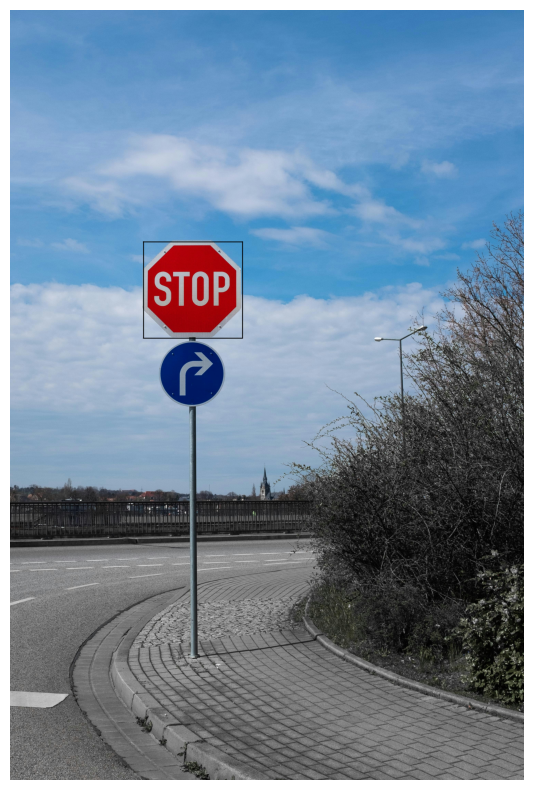

In [22]:

# buscar el valor máximo en la matriz de distancias
max_distancia = np.max(distancias)
print(f'El valor máximo en la matriz de distancias es: {max_distancia}')

# Encontrar la posición del valor máximo
pos_max = np.unravel_index(np.argmax(distancias), distancias.shape) 
print(f'La posición del valor máximo es: {pos_max}')

stride = 25
i = pos_max[0]
j = pos_max[1]

imagen = cv2.imread('foto.jpg')
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

filas_i, columnas_i = imagen.shape[:2]
filas_v, columnas_v = ventana.shape[:2]

imagen_marco = np.ones((filas_i, columnas_i, 3))  # Aseguramos que es un array de NumPy    
cuadrado = np.ones((filas_v, columnas_v, 3))  # Aseguramos que es un array de NumPy    

Relleno = 0

# 2. Dibujar el marco (asignar 1 a los bordes)
for k in range(5):  # Para un marco de 3 píxeles de grosor
    cuadrado[   k+1,      :] = Relleno # Fila superior
    cuadrado[-(k+1),      :] = Relleno # Fila inferior
    cuadrado[:     ,    k+1] = Relleno # Columna izquierda
    cuadrado[:     , -(k+1)] = Relleno # Columna derecha

imagen_marco[i*stride:(i*stride)+filas_v, j*stride:(j*stride)+columnas_v] = cuadrado

imagen_marco = imagen_marco.astype(np.uint8)  # Convertimos a uint8 para visualizar correctamente

imagen_salida = imagen * imagen_marco  # Combina la imagen original con el marco   

# 3. Visualizar la imagen con el marco
plt.figure(figsize=(10, 10))        
plt.imshow(imagen_salida, cmap='gray')
plt.axis("off") 
